# Анализ результатов бенчмаркинга моделей детекции объектов

Ноутбук содержит визуальный анализ метрик точности и быстродействия для семейств архитектур LibreDFINE, LibreRTDETR, LibreRFDETR, LibreYOLO9, LibreYOLOX, LibreDEIM на датасете COCO 2017 val.

**Оборудование:** RTX 3060 Laptop (6 ГБ), AMD Ryzen 5 5600H  
**Формат инференса:** ONNX FP32, batch=1, CUDAExecutionProvider  
**Метрика:** COCO AP (IoU=0.50:0.95), если не указано иное

# Методология проведения исследования

## Исследуемые архитектуры
В ходе работы проводилась сравнительная оценка нескольких семейств нейросетевых моделей в различных конфигурациях (в зависимости от числа параметров). Сбор метаданных осуществлялся посредством скрипта `1_model_stats.py`:
* **Архитектуры на базе трансформеров (DETR/DFINE):** LibreDFINE (n, s, m, l, x), LibreRFDETR (n, s, m, l), LibreRTDETR (r18, r34, r50m, v2r50m, v4m, v4x).
* **Сверточные архитектуры (YOLO/DEIM):** LibreYOLO9 (t, s, m, c), LibreYOLO9E2E (t, s, m, c), LibreYOLOX (n, t, s, m, l, x), LibreDEIM (n, s, m, l, x), LibreDEIMv2 (n, s, m, l, x).

## Параметры инференса
* **Размерность входного тензора:** 640x640 пикселей (за исключением моделей LibreYOLOX n/t, для которых применялось разрешение 416x416). Масштабирование изображений выполнялось методом Letterbox.
* **Порог достоверности (Confidence Threshold):** 0.001 (снижен для обеспечения корректного расчета метрик mAP по стандарту COCO).
* **Порог подавления немаксимумов (NMS IoU):** 0.65.
* **Размер пакета (Batch Size):** 1 (последовательная обработка кадров).
* **Формат данных:** FP32 (числа с плавающей запятой одинарной точности).
* **Тестовая выборка:** Набор данных COCO 2017 Validation (5000 изображений).


# Ход работы

Процесс проведения вычислительных экспериментов был разделен на два независимых конвейера с учетом специфики архитектур, алгоритмов постпроцессинга и форматов экспорта моделей. На финальном этапе результаты обоих конвейеров агрегировались в общую базу данных.

### Конвейер №1: Оценка архитектур на базе трансформеров (DETR, DFINE)
Для моделей семейств LibreDFINE, LibreRTDETR и LibreRFDETR применялся строгий поэтапный подход с последовательным запуском изолированных скриптов:
1. **Подготовка моделей (`0_download_and_export.py`):** Загрузка PyTorch-весов (.pt) и их конвертация в открытый формат ONNX.
2. **Сбор статистики (`1_model_stats.py`):** Вычисление структурных параметров графов, физического объема файлов и генерация контрольных сумм (MD5).
3. **Генерация предсказаний (`2_generate_predictions.py`):** Обработка датасета COCO2017 с сохранением сырых детекций в формате JSON.
4. **Расчет точности (`3_calculate_metrics.py`):** Вычисление метрик Average Precision (mAP) и построение PR-кривых с использованием библиотеки `pycocotools`.
5. **Оценка быстродействия (`4_measure_speed.py`):** Изолированное профилирование кадровой частоты (FPS) и задержки (Latency) после инициализации и "прогрева" GPU.

### Конвейер №2: Оценка сверточных архитектур (YOLO, YOLOX, DEIM)
Для семейств LibreYOLO9 (вкл. E2E), LibreYOLOX и LibreDEIM (v1/v2) использовался интегрированный пайплайн, управляемый единым скриптом-оркестратором `run_pipeline.py`:
1. **Специфичный инференс:** Инференс выполнялся через специализированные модули (`inference_LibreYOLO9.py`, `inference_LibreYOLOX.py`, `inference_LibreDEIM.py`), учитывающие топологию выходных тензоров. Препроцессинг включал метод масштабирования Letterbox. Постпроцессинг реализовывал расчет логитов (Sigmoid), масштабирование координат и алгоритм подавления немаксимумов (NMS) с помощью `cv2.dnn.NMSBoxes` (за исключением моделей E2E).
2. **Профилирование времени:** Замер времени обработки кадра (`time.perf_counter()`) выполнялся непосредственно внутри цикла инференса, а усредненное значение передавалось в оркестратор через стандартный поток вывода (`stdout`).
3. **Автоматизированная оценка (`evaluate.py`):** По завершении генерации JSON-файла для каждой модели оркестратор автоматически вызывал модуль оценки, который рассчитывал метрики COCO и генерировал визуализацию PR-кривых (`matplotlib.pyplot`).
4. **Локальная агрегация:** Полученные метрики точности и скорости автоматически логировались в промежуточные файлы `yolo_deim_metrics.csv` и `yolo_deim_speed.csv`.

### Интеграция данных
На заключительном этапе скрипт `merge_reports.py` производил слияние CSV-файлов из обоих вычислительных конвейеров. Производился перерасчет временных задержек в FPS, после чего формировался итоговый аналитический датафрейм `benchmark_all_models.csv`, послуживший основой для генерации сводной таблицы и графиков.


# Анализ полученных результатов

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np
from pathlib import Path
from matplotlib.image import imread

try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False

RESULTS_DIR  = Path('results')
PR_DIR       = RESULTS_DIR / 'pr_curves'
ANALYSIS_DIR = RESULTS_DIR / 'analysis_plots'
ANALYSIS_DIR.mkdir(exist_ok=True)
CSV_PATH     = RESULTS_DIR / 'benchmark_all_models.csv'

FAMILY_COLORS = {
    'LibreDFINE':    '#1f77b4',
    'LibreRFDETR':   '#ff7f0e',
    'LibreRTDETR':   '#2ca02c',
    'LibreYOLO9':    '#d62728',
    'LibreYOLO9E2E': '#9467bd',
    'LibreYOLOX':    '#8c564b',
    'LibreDEIM':     '#e377c2',
    'LibreDEIMv2':   '#7f7f7f',
}

SIZE_ORDER = ['n','t','r18','r34','s','m','r50m','v2r50m','v4m','l','c','x','v4x']

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
    'figure.dpi':        110,
})

print('Импорты выполнены.')

Импорты выполнены.


## 1. Загрузка и предобработка данных

In [9]:
def parse_family_size(name):
    """Возвращает кортеж (семейство, код_размера) для имени модели."""
    if 'RTDETR' in name:
        for suffix in ['v2r50m', 'v4x', 'v4m', 'v2r18', 'r50m', 'r34', 'r18']:
            if name.endswith(suffix):
                return name[:-len(suffix)], suffix
    return name[:-1], name[-1]

df = pd.read_csv(CSV_PATH)
df[['Family', 'Size_Code']] = df['Модель'].apply(
    lambda n: pd.Series(parse_family_size(n))
)
df['FPS']     = pd.to_numeric(df['FPS'],     errors='coerce')
df['Time_ms'] = pd.to_numeric(df['Time_ms'], errors='coerce')
df = df.dropna(subset=['FPS'])

size_rank = {s: i for i, s in enumerate(SIZE_ORDER)}
df['Size_Rank'] = df['Size_Code'].map(size_rank)

print(f'Загружено моделей: {len(df)}')
print(f'Семейства: {sorted(df["Family"].unique())}')
df.sort_values('mAP50-95', ascending=False).head(10)[
    ['Модель','Family','Size_Code','mAP50-95','FPS','Time_ms']
]

Загружено моделей: 39
Семейства: ['LibreDEIM', 'LibreDEIMv2', 'LibreDFINE', 'LibreRFDETR', 'LibreRTDETR', 'LibreYOLO9', 'LibreYOLO9E2E', 'LibreYOLOX']


,Модель,Family,Size_Code,mAP50-95,FPS,Time_ms
6,LibreDFINEx,LibreDFINE,x,0.5844,14.27,70.06
13,LibreDFINEl,LibreDFINE,l,0.5634,17.78,56.24
4,LibreRTDETRv4x,LibreRTDETR,v4x,0.5523,14.64,68.31
38,LibreDEIMv2x,LibreDEIMv2,x,0.5475,10.92,91.59
33,LibreDEIMx,LibreDEIM,x,0.5446,14.76,67.77
12,LibreDFINEm,LibreDFINE,m,0.5410,22.84,43.79
2,LibreRFDETRl,LibreRFDETR,l,0.5380,19.60,51.03
32,LibreDEIMl,LibreDEIM,l,0.5275,19.15,52.21
37,LibreDEIMv2l,LibreDEIMv2,l,0.5223,13.23,75.59
3,LibreRFDETRm,LibreRFDETR,m,0.5198,26.10,38.32


## 2. Кривые Precision-Recall по семействам архитектур

Для каждого семейства все размерные конфигурации упорядочены по возрастанию mAP@0.50:0.95.
Подпись над каждым графиком содержит код размера и значение метрики.

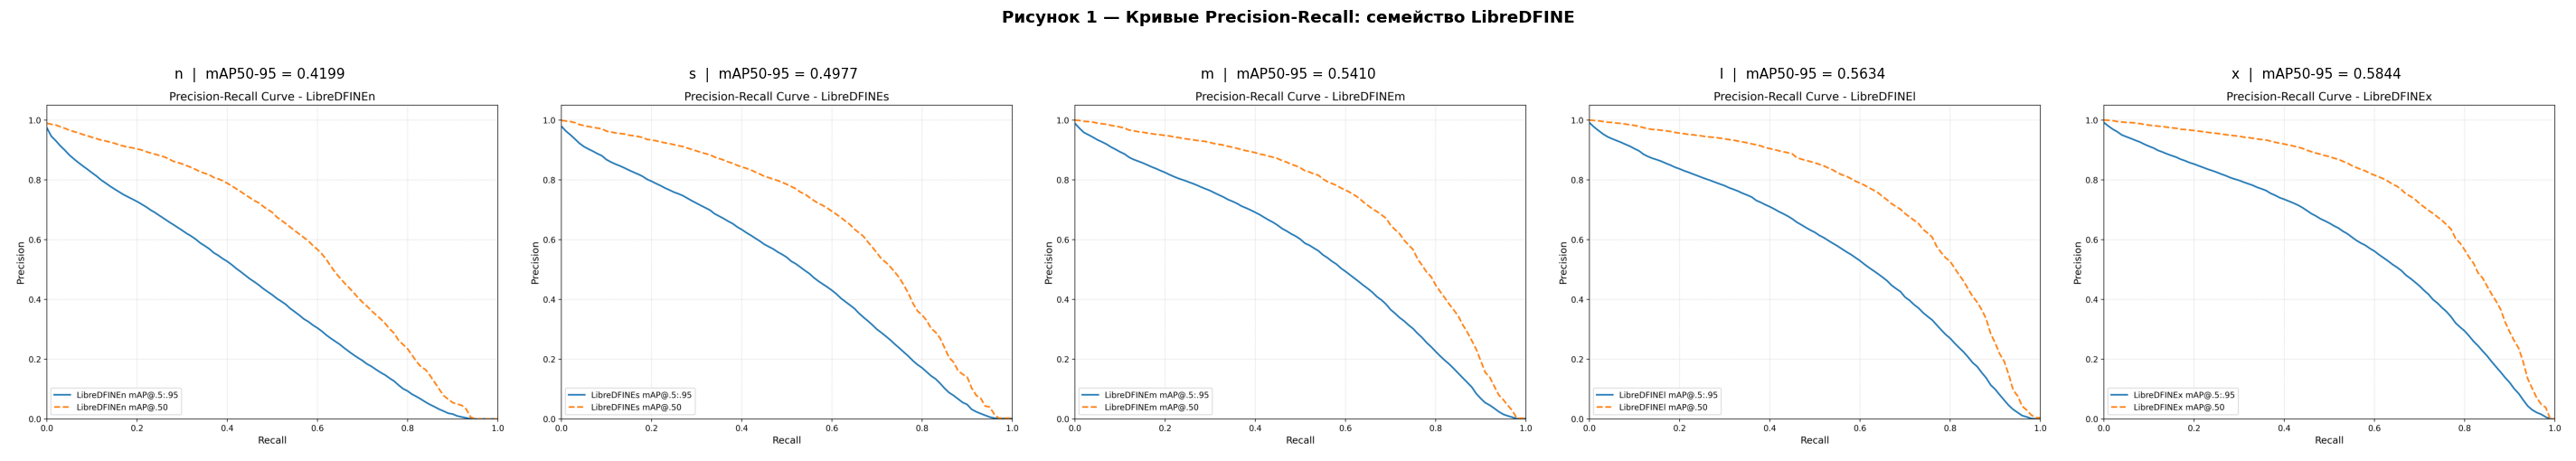

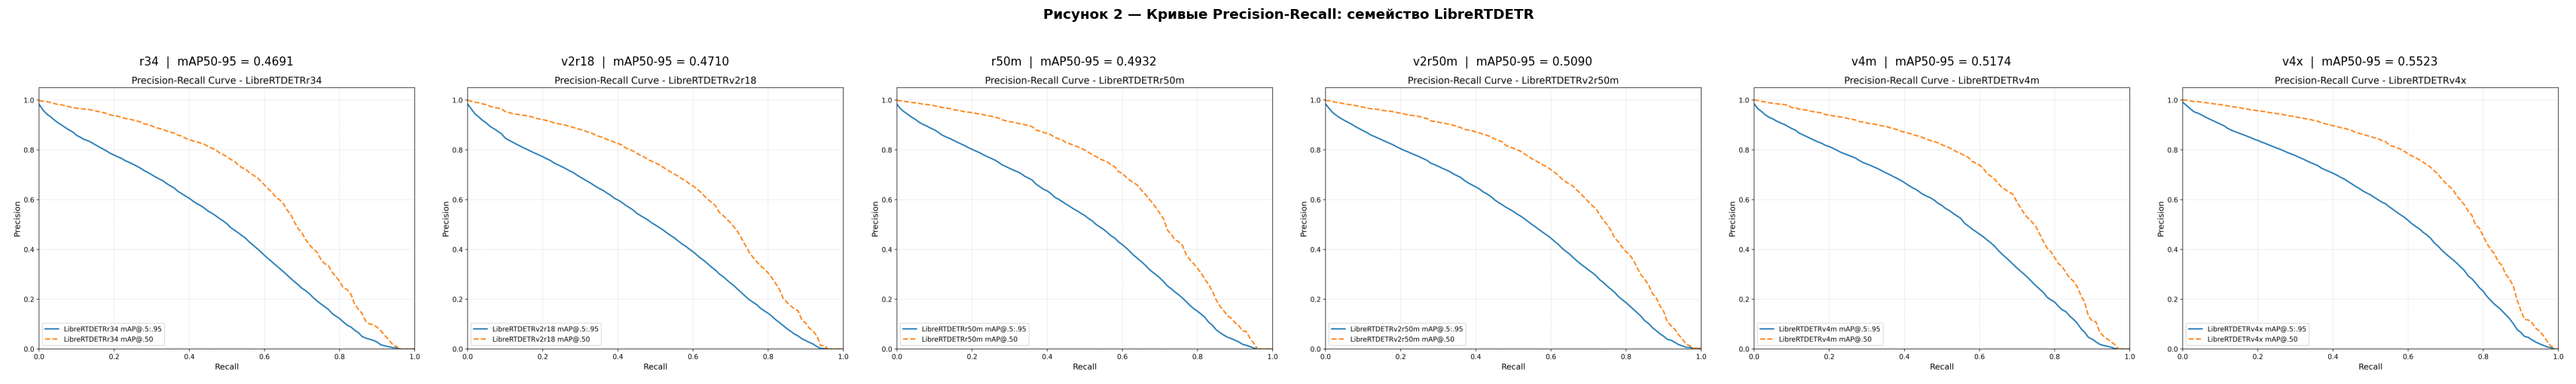

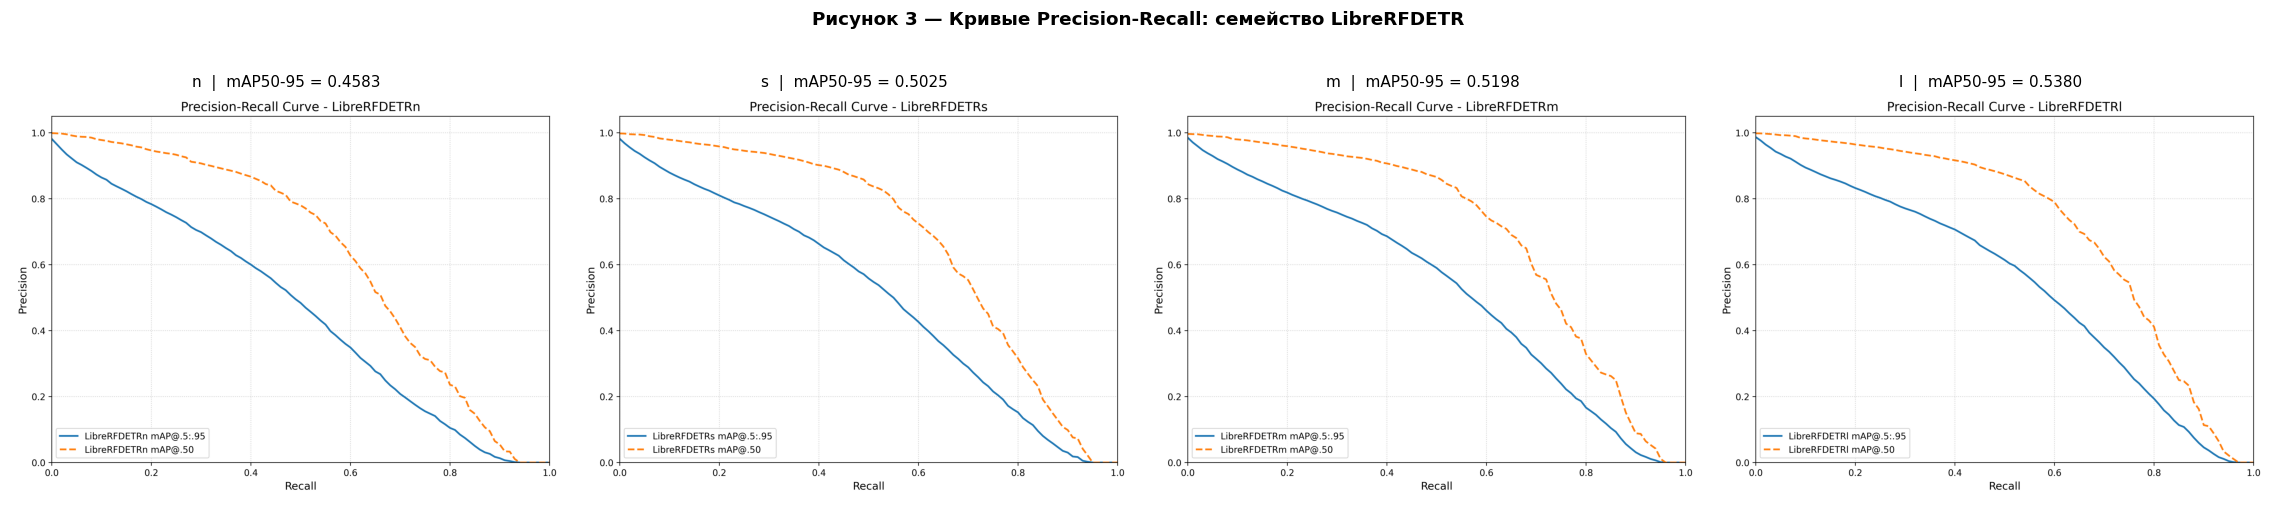

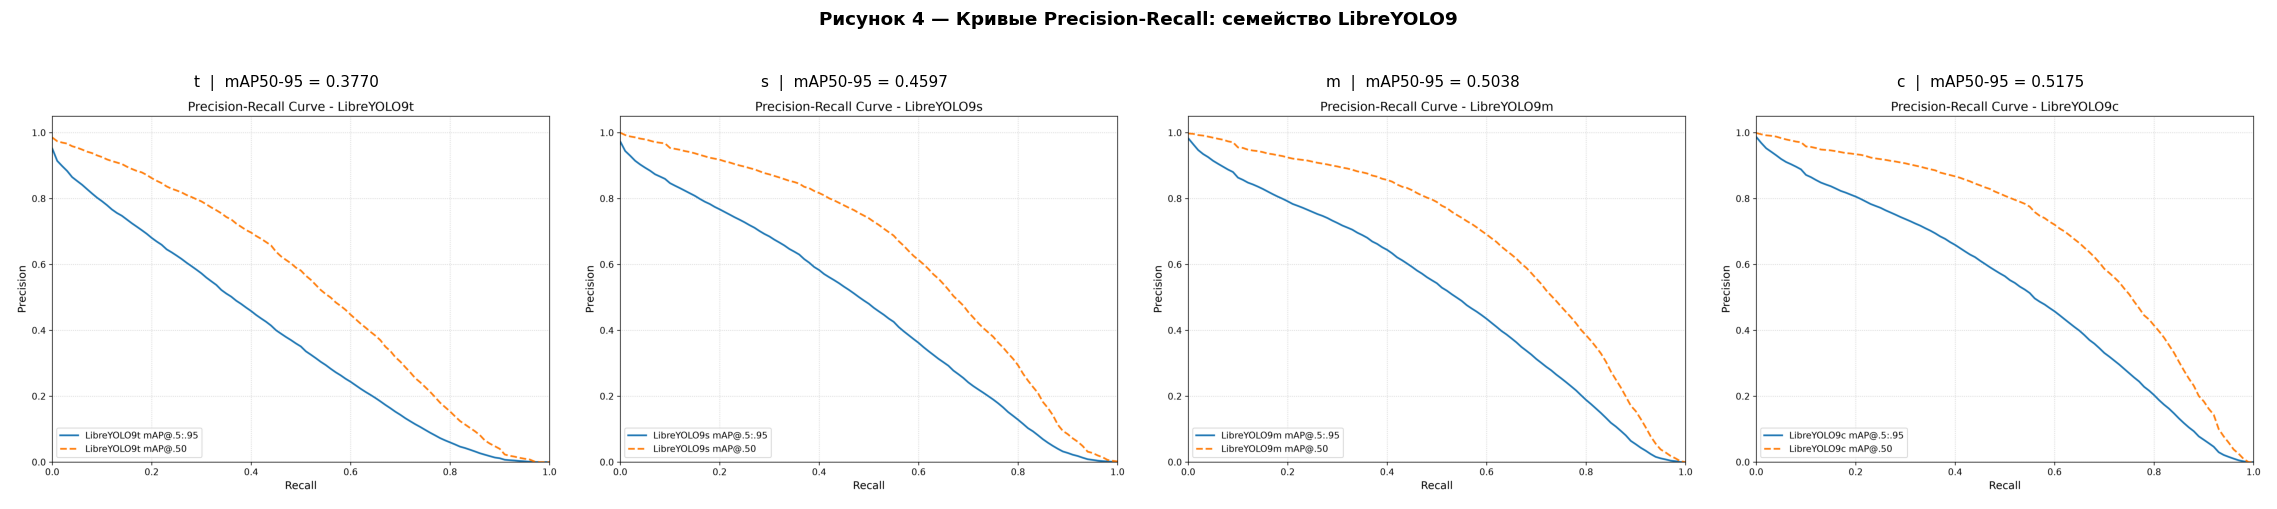

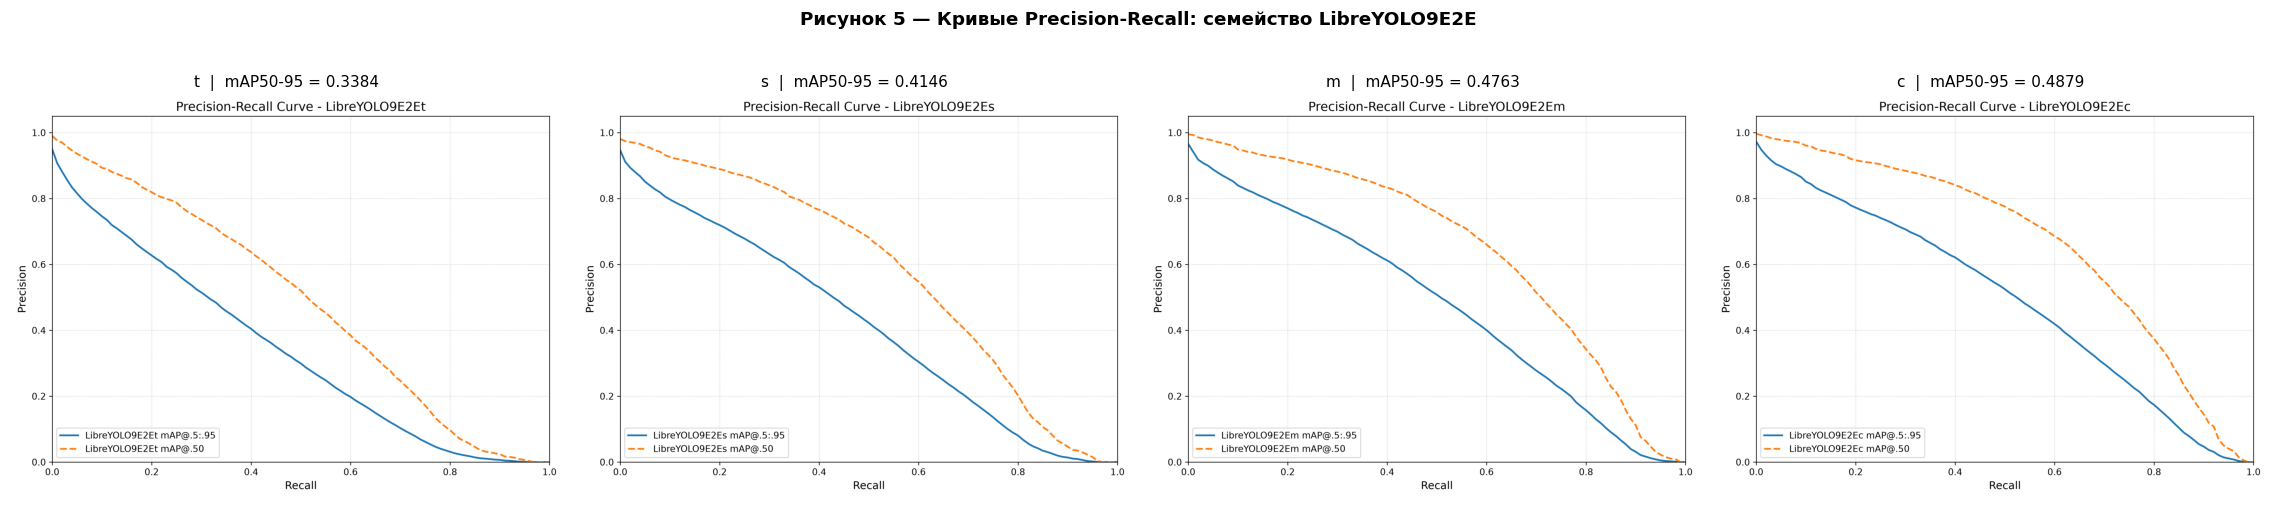

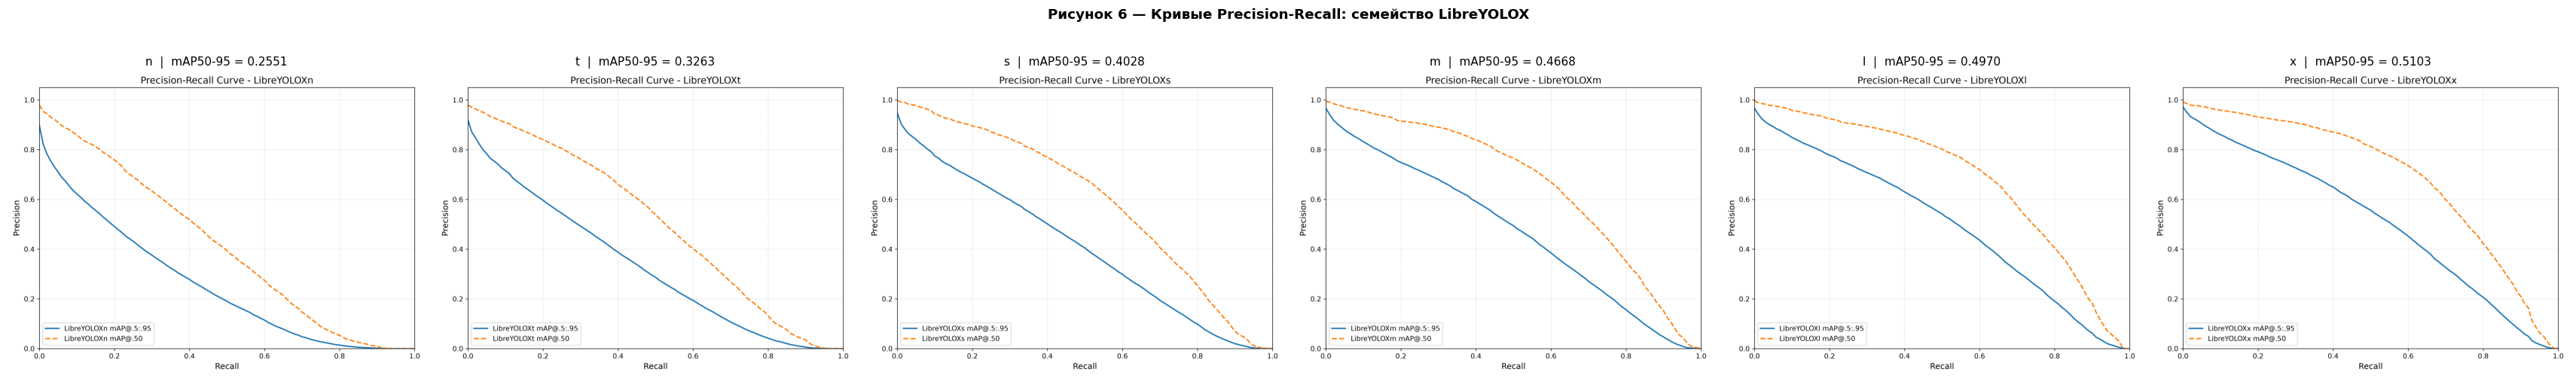

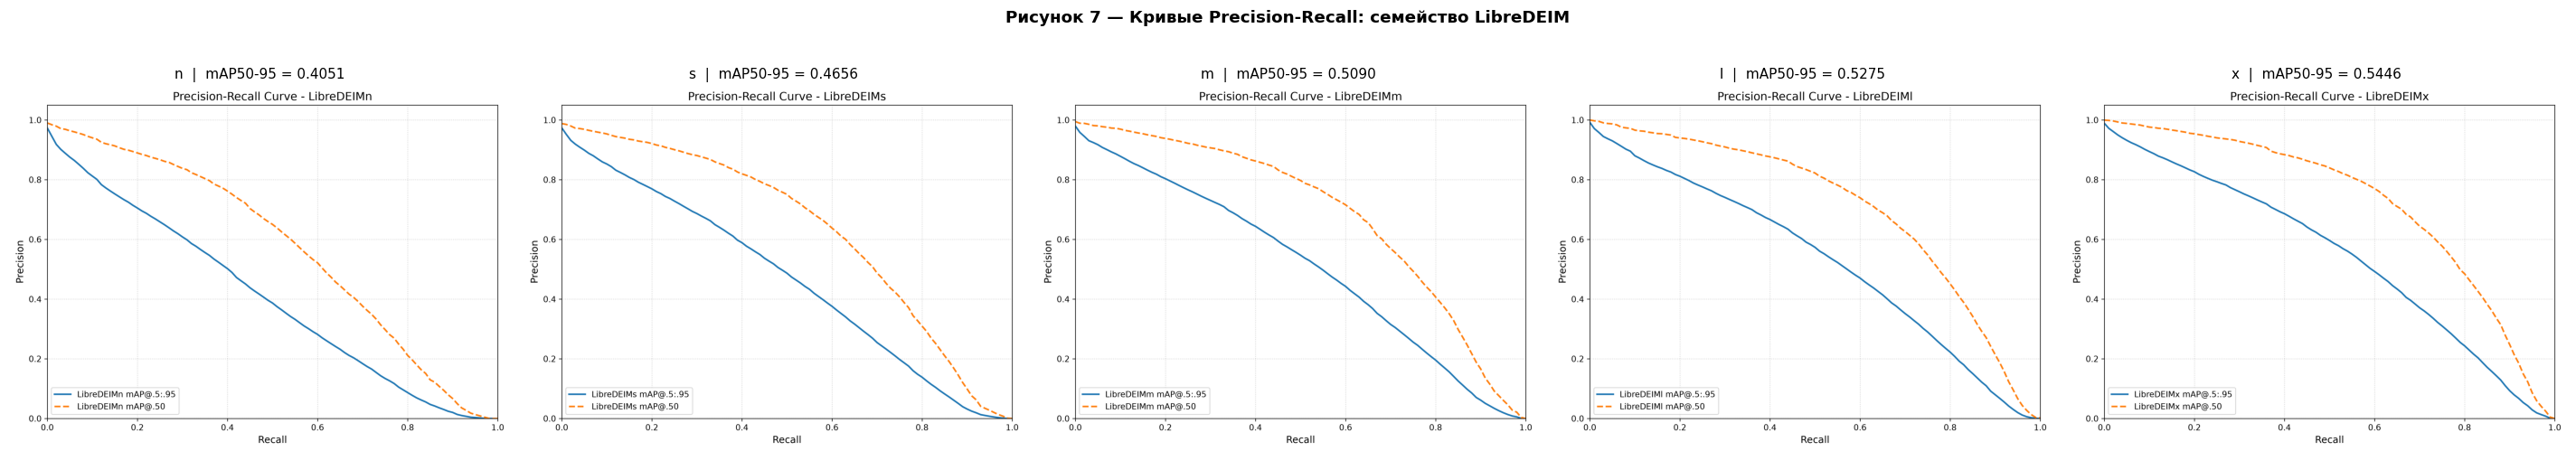

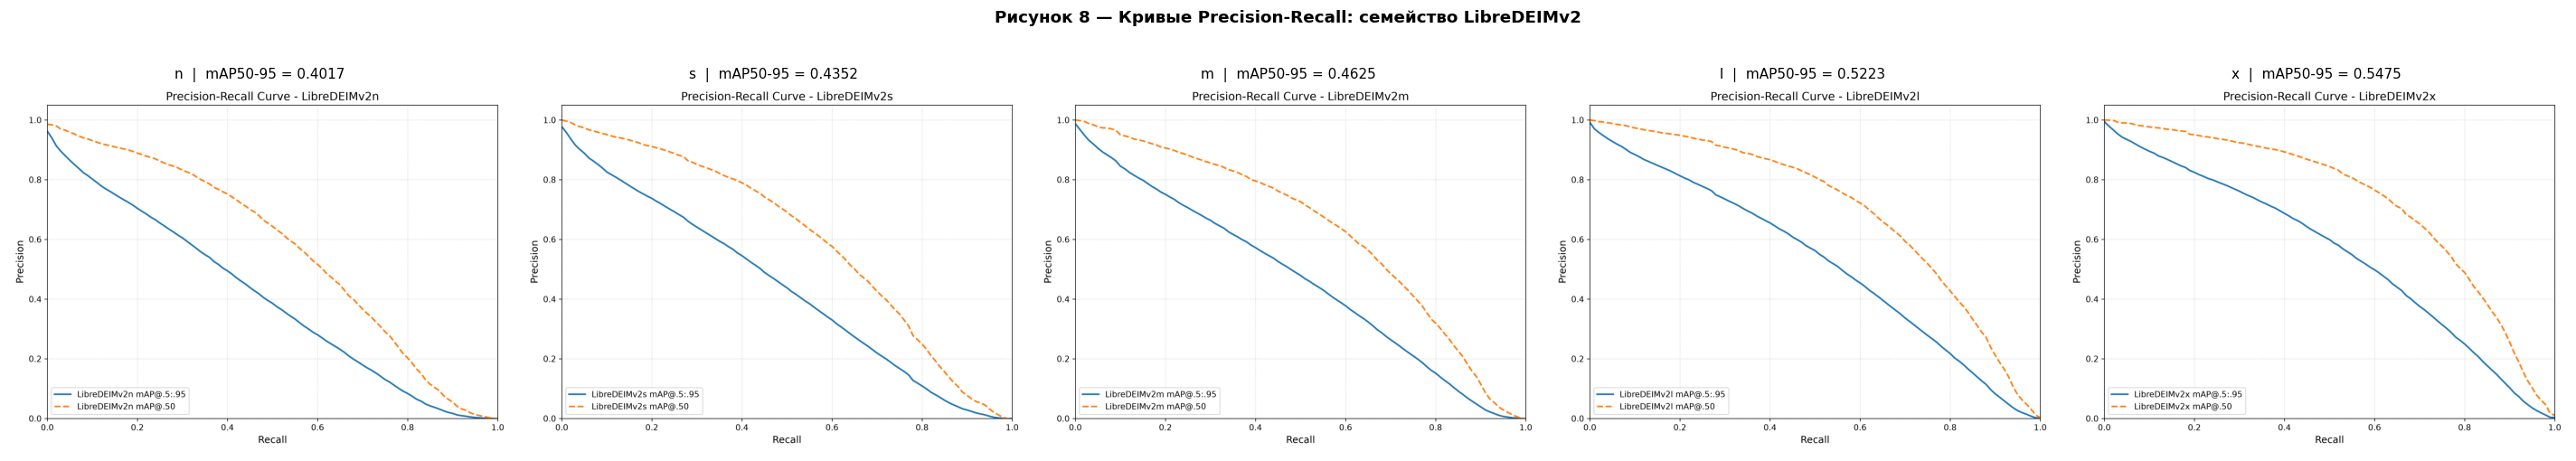

In [24]:
def get_pr_files_for_family(family):
    """Возвращает список (mAP, model_name, Path) для семейства, отсортированный по mAP."""
    result = []
    for f in sorted(PR_DIR.glob('PR_*.png')):
        model_name = f.stem[3:]
        fam, _ = parse_family_size(model_name)
        if fam != family:
            continue
        row = df[df['Модель'] == model_name]
        mv  = float(row['mAP50-95'].values[0]) if len(row) else 0.0
        result.append((mv, model_name, f))
    return sorted(result, key=lambda x: x[0])

families_ordered = [
    'LibreDFINE', 'LibreRTDETR', 'LibreRFDETR',
    'LibreYOLO9', 'LibreYOLO9E2E', 'LibreYOLOX',
    'LibreDEIM', 'LibreDEIMv2',
]
families_ordered = [f for f in families_ordered
                    if any(True for fp in PR_DIR.glob('PR_*.png')
                           if parse_family_size(fp.stem[3:])[0] == f)]

fig_num = 1
for family in families_ordered:
    entries = get_pr_files_for_family(family)
    if not entries:
        continue
    n = len(entries)
    fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 4.8))
    if n == 1:
        axes = [axes]

    for col, (mv, model_name, fpath) in enumerate(entries):
        img = imread(str(fpath))
        axes[col].imshow(img)
        axes[col].axis('off')
        short = model_name.replace(family, '')
        axes[col].set_title(
            f'{short}  |  mAP50-95 = {mv:.4f}',
            fontsize=10, pad=6
        )

    fig.suptitle(
        f'Рисунок {fig_num} — Кривые Precision-Recall: семейство {family}',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    safe_name = family.replace('/', '_')
    plt.savefig(ANALYSIS_DIR / f'pr_family_{safe_name}.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    fig_num += 1

### Трансформеры
- Качество обводки: Тяжелые конфигурации трансформеров, в частности DFINEx, формируют широкое плато. Это свидетельствует о сохранении высокой точности локализации даже при строгих порогах пересечения.
- Снижение метрик: Легкие модели, в частности RFDETRn, демонстрируют резкое падение метрики при увеличении порога уверенности из-за снижения качества совпадения предсказанных рамок с эталонными.

### CNN
- Качество локализации объектов сверточными нейросетями напрямую зависит от масштаба и вычислительной емкости их архитектуры. 
- Структурное упрощение сети ради ускорения инференса неизбежно приводит к резкому падению точности при попытке повысить полноту обнаружения. 
- Напротив, глубокие флагманские конфигурации CNN способны поддерживать высокую стабильность предсказаний даже при максимальном охвате объектов.

## 3. Граница Парето: быстродействие и точность

Граница Парето выделяет множество моделей, для которых невозможно одновременно
увеличить точность и скорость инференса без ухудшения одного из показателей.
Размер маркера пропорционален времени обработки кадра.

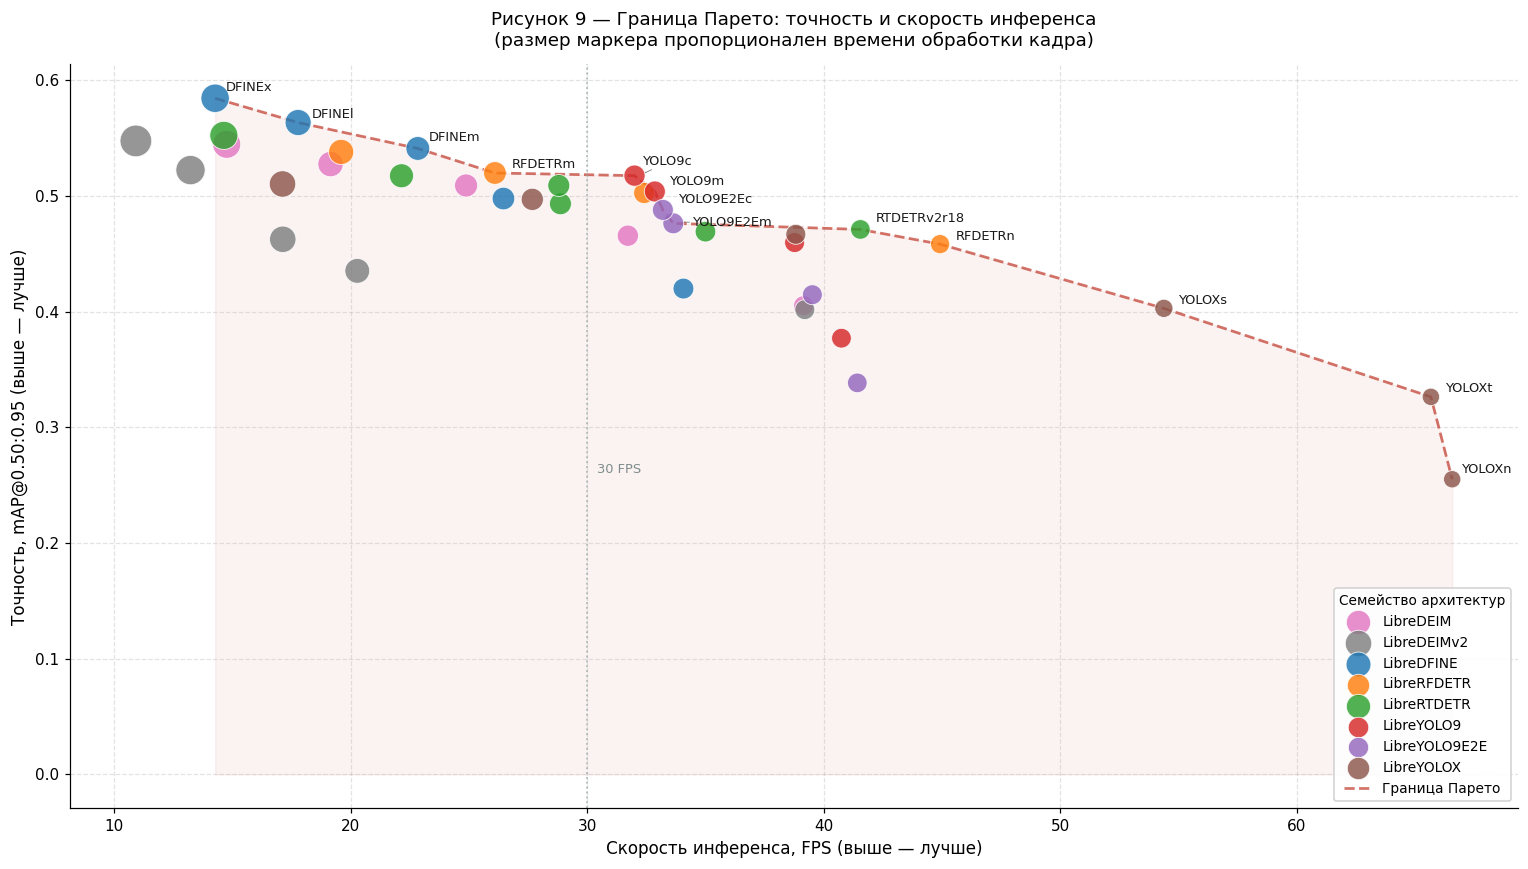

Модели на границе Парето (13 шт.):
          Модель  mAP50-95   FPS  Time_ms
     LibreDFINEx    0.5844 14.27    70.06
     LibreDFINEl    0.5634 17.78    56.24
     LibreDFINEm    0.5410 22.84    43.79
    LibreRFDETRm    0.5198 26.10    38.32
     LibreYOLO9c    0.5175 32.00    31.25
     LibreYOLO9m    0.5038 32.86    30.43
  LibreYOLO9E2Ec    0.4879 33.20    30.12
  LibreYOLO9E2Em    0.4763 33.64    29.73
LibreRTDETRv2r18    0.4710 41.55    24.07
    LibreRFDETRn    0.4583 44.92    22.26
     LibreYOLOXs    0.4028 54.38    18.39
     LibreYOLOXt    0.3263 65.67    15.23
     LibreYOLOXn    0.2551 66.57    15.02


In [25]:
def get_pareto_frontier(df_, x_col, y_col):
    sorted_df = df_.sort_values(by=x_col, ascending=False).reset_index(drop=True)
    pareto  = [sorted_df.iloc[0]]
    max_y   = sorted_df.iloc[0][y_col]
    for i in range(1, len(sorted_df)):
        if sorted_df.iloc[i][y_col] > max_y:
            pareto.append(sorted_df.iloc[i])
            max_y = sorted_df.iloc[i][y_col]
    return pd.DataFrame(pareto).sort_values(by=x_col)

pareto_df = get_pareto_frontier(df, 'FPS', 'mAP50-95')

fig, ax = plt.subplots(figsize=(14, 8))

for family, grp in df.groupby('Family'):
    color = FAMILY_COLORS.get(family, '#aaaaaa')
    sizes = (grp['Time_ms'] / df['Time_ms'].max() * 360 + 70).values
    ax.scatter(grp['FPS'], grp['mAP50-95'],
               color=color, s=sizes, alpha=0.82,
               edgecolors='white', linewidths=0.6,
               label=family, zorder=3)

ax.plot(pareto_df['FPS'], pareto_df['mAP50-95'],
        color='#c0392b', linestyle='--', linewidth=1.8,
        alpha=0.7, label='Граница Парето', zorder=2)
ax.fill_between(pareto_df['FPS'], pareto_df['mAP50-95'],
                alpha=0.06, color='#c0392b', zorder=1)

texts = []
for _, row in pareto_df.iterrows():
    t = ax.text(
        row['FPS'] + 0.3, row['mAP50-95'] + 0.001,
        row['Модель'].replace('Libre', ''),
        fontsize=8.5, color='#1a1a1a'
    )
    texts.append(t)
if HAS_ADJUST_TEXT:
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='->', color='#888888', lw=0.6))

ax.axvline(30, color='#95a5a6', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(30.4, df['mAP50-95'].min() + 0.005, '30 FPS',
        fontsize=8.5, color='#7f8c8d')

ax.set_xlabel('Скорость инференса, FPS (выше — лучше)', fontsize=11)
ax.set_ylabel('Точность, mAP@0.50:0.95 (выше — лучше)', fontsize=11)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9,
          title='Семейство архитектур', title_fontsize=9)

plt.title(
    'Рисунок 9 — Граница Парето: точность и скорость инференса\n'
    '(размер маркера пропорционален времени обработки кадра)',
    fontsize=12, pad=12
)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / '9_pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Модели на границе Парето ({len(pareto_df)} шт.):')
print(pareto_df[['Модель','mAP50-95','FPS','Time_ms']].to_string(index=False))

- Максимальная точность: Семейство DFINE доминирует в тяжелом сегменте. Модель DFINEx обеспечивает наивысшую точность при скорости обработки менее 15 кадров в секунду.
- Сбалансированная зона: YOLO9 модели доминируют. Трансформеры RTDETR и RFDETR демонстрируют результаты, сопоставимые со сверточными моделями YOLO9, в диапазоне частоты от 25 до 45 кадров в секунду.
- Максимальное быстродействие: При частоте кадров свыше 50 доминируют модели семейства YOLOX, однако прирост скорости сопровождается падением целевой метрики ниже значения 0.40.

## 4. Анализ масштабируемости архитектур

Зависимость mAP@0.50:0.95 от размерной конфигурации модели внутри каждого семейства.
Трансформерные и сверточные семейства представлены раздельно.

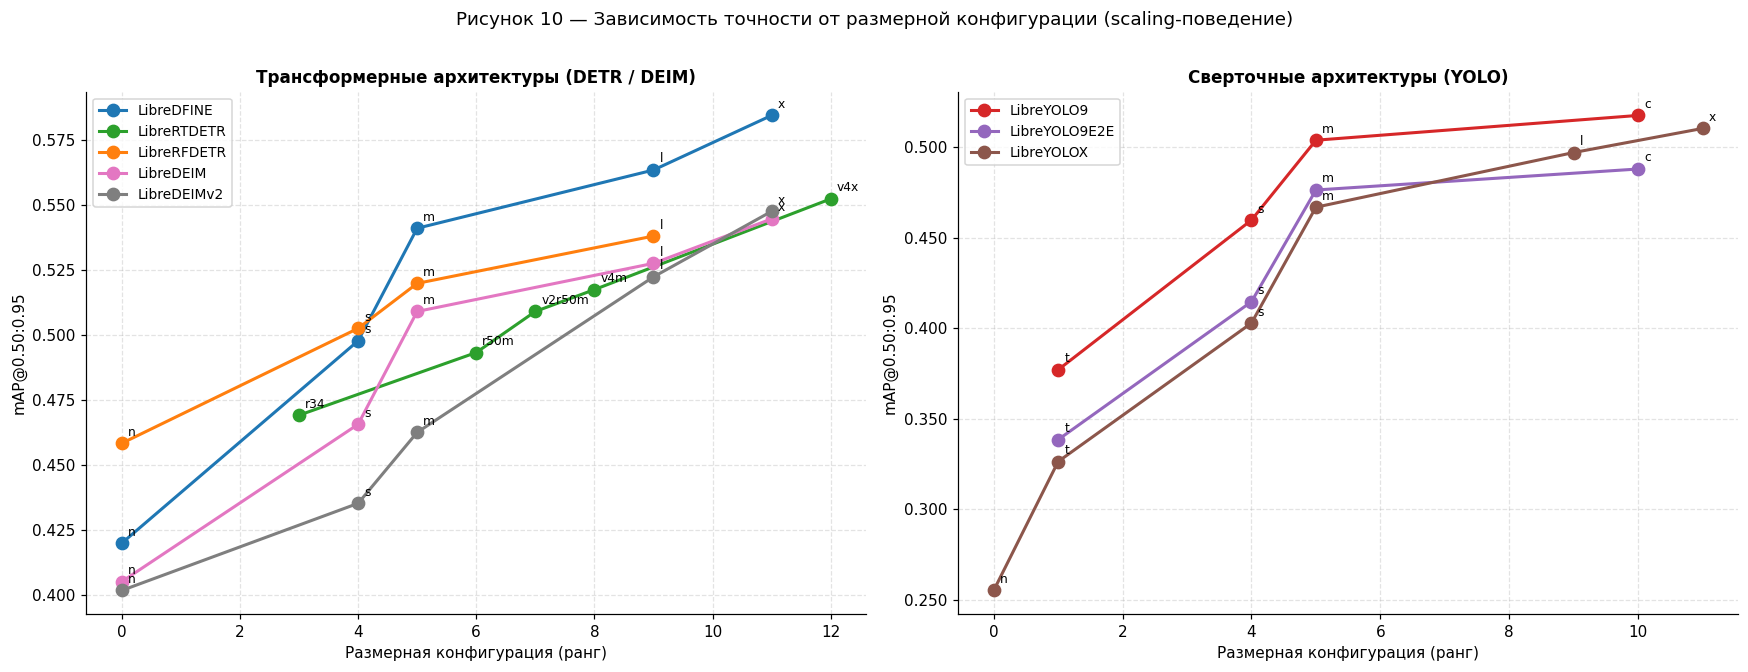

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

groups = [
    ('Трансформерные архитектуры (DETR / DEIM)',
     ['LibreDFINE', 'LibreRTDETR', 'LibreRFDETR', 'LibreDEIM', 'LibreDEIMv2'],
     axes[0]),
    
    ('Сверточные архитектуры (YOLO)',
     ['LibreYOLO9', 'LibreYOLO9E2E', 'LibreYOLOX'],
     axes[1]),
]
for title, families, ax in groups:
    for family in families:
        grp = df[df['Family'] == family].dropna(subset=['Size_Rank']).sort_values('Size_Rank')
        if grp.empty:
            continue
        color = FAMILY_COLORS.get(family, '#aaaaaa')
        ax.plot(grp['Size_Rank'], grp['mAP50-95'],
                color=color, marker='o', linewidth=2,
                markersize=8, label=family)
        for _, row in grp.iterrows():
            ax.annotate(
                row['Size_Code'],
                (row['Size_Rank'], row['mAP50-95']),
                textcoords='offset points', xytext=(4, 5), fontsize=8
            )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Размерная конфигурация (ранг)', fontsize=10)
    ax.set_ylabel('mAP@0.50:0.95', fontsize=10)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

fig.suptitle(
    'Рисунок 10 — Зависимость точности от размерной конфигурации (scaling-поведение)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / '10_scaling_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Трансформерные архитектуры (DETR / DEIM)


*   **Ультралегкий сегмент:** На минимальных весовых конфигурациях модель LibreRFDETRn удерживает лидерство, демонстрируя более высокие метрики по сравнению с базовой версией LibreDFINEn. Семейства LibreDEIM в нано-размерах стартуют с более скромных позиций (mAP ~0.40).
*   **Динамика роста и тяжелый сегмент:** По мере наращивания параметров архитектура LibreDFINE показывает  нелинейный рост точности, становясь лидером среди всех представленных моделей в старших конфигурациях ('x').
*   **Поведение DEIM и RTDETR:** Семейства LibreDEIM и LibreDEIMv2 показывают уверенный рост, сопоставимый по финальным значениям с тяжелыми версиями LibreRTDETR. При этом архитектура LibreRTDETR демонстрирует наиболее стабильный, почти линейный прирост метрик от версии к версии, хотя и уступает флагману DFINE по абсолютной точности.

#### Сверточные архитектуры (YOLO)

*   **Ультралегкий сегмент:** В классе малых моделей безоговорочным лидером является LibreYOLO9. В то же время, архитектура LibreYOLOX демонстрирует крайне низкую эффективность на нано-конфигурации ('n' с mAP ~0.25), что говорит о плохой масштабируемости этой архитектуры "вниз".
*   **Средний сегмент и скачок YOLOX:** При переходе к средним весам ('m') наблюдается резкий рост точности всех моделей. Особенно примечателен LibreYOLOX, который благодаря крутой кривой масштабирования практически полностью компенсирует свое изначальное отставание от семейства YOLO9.
*   **Эффект плато в старших версиях:** Для семейств LibreYOLO9 и LibreYOLO9E2E характерен ранний эффект насыщения (плато) — после конфигурации 'm' (ранг 5) рост метрик критически замедляется. В противовес им, LibreYOLOX продолжает стабильно расти вплоть до версии 'x', практически догоняя базовый YOLO9.
*   **Специфика End-to-End (E2E):** Версия LibreYOLO9E2E на всех размерных конфигурациях показывает систематическое отставание от базового LibreYOLO9, а на старших весах страдает от самой сильной стагнации метрик.

## 5. Точность по размерным классам объектов (AP_S, AP_M, AP_L)

Для каждого семейства выбрана наилучшая модель по mAP@0.50:0.95.
Пунктирная линия — общий mAP@0.50:0.95 данной модели (ориентир).

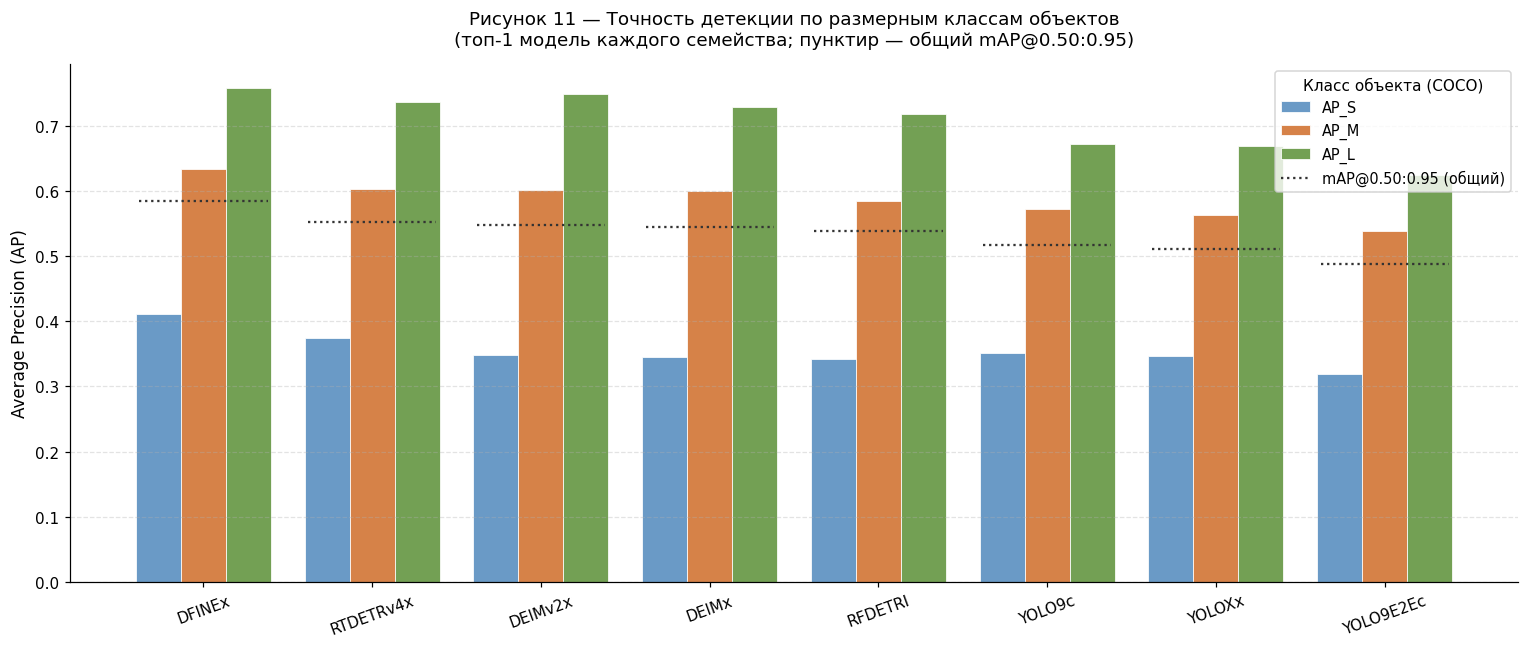

In [27]:
top_models = (
    df.loc[df.groupby('Family')['mAP50-95'].idxmax()]
    .sort_values('mAP50-95', ascending=False)
    .reset_index(drop=True)
)

melted = pd.melt(
    top_models,
    id_vars=['Модель', 'Family', 'mAP50-95'],
    value_vars=['mAP small', 'mAP medium', 'mAP large'],
    var_name='Класс объекта',
    value_name='AP'
)
melted['Класс объекта'] = melted['Класс объекта'].map({
    'mAP small':  'AP_S',
    'mAP medium': 'AP_M',
    'mAP large':  'AP_L',
})
melted['Модель_short'] = melted['Модель'].str.replace('Libre', '', regex=False)

palette = {'AP_S': '#5b9bd5', 'AP_M': '#ed7d31', 'AP_L': '#70ad47'}

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=melted, x='Модель_short', y='AP', hue='Класс объекта',
    palette=palette, edgecolor='white', linewidth=0.5, ax=ax
)

# Пунктир — общий mAP50-95
for i, row in top_models.reset_index().iterrows():
    ax.plot([i - 0.38, i + 0.38],
            [row['mAP50-95'], row['mAP50-95']],
            color='#333333', linewidth=1.5, linestyle=':', zorder=5)

legend_line = Line2D([0],[0], color='#333333', linewidth=1.5,
                     linestyle=':', label='mAP@0.50:0.95 (общий)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [legend_line], labels + ['mAP@0.50:0.95 (общий)'],
          fontsize=9.5, title='Класс объекта (COCO)', title_fontsize=10)

ax.set_xlabel('', fontsize=10)
ax.set_ylabel('Average Precision (AP)', fontsize=11)
ax.tick_params(axis='x', rotation=20)

plt.title(
    'Рисунок 11 — Точность детекции по размерным классам объектов\n'
    '(топ-1 модель каждого семейства; пунктир — общий mAP@0.50:0.95)',
    fontsize=12, pad=12
)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / '11_map_by_object_size.png', dpi=150, bbox_inches='tight')
plt.show()

- Общая тенденция: Для всех протестированных моделей распознавание малоразмерных объектов представляет наибольшую алгоритмическую сложность.
- Лидер сегмента: Модель DFINEx является единственной архитектурой, преодолевшей порог точности 0.40 на малых объектах, что подтверждает эффективность применения механизма глобального внимания при анализе мелких деталей.

## 6. Деградация точности при ужесточении порога IoU: mAP@0.50 vs mAP@0.75

Диагональ y = x соответствует нулевой деградации.
Чем ниже точка относительно диагонали, тем сильнее модель теряет качество
при переходе с IoU=0.50 к IoU=0.75.

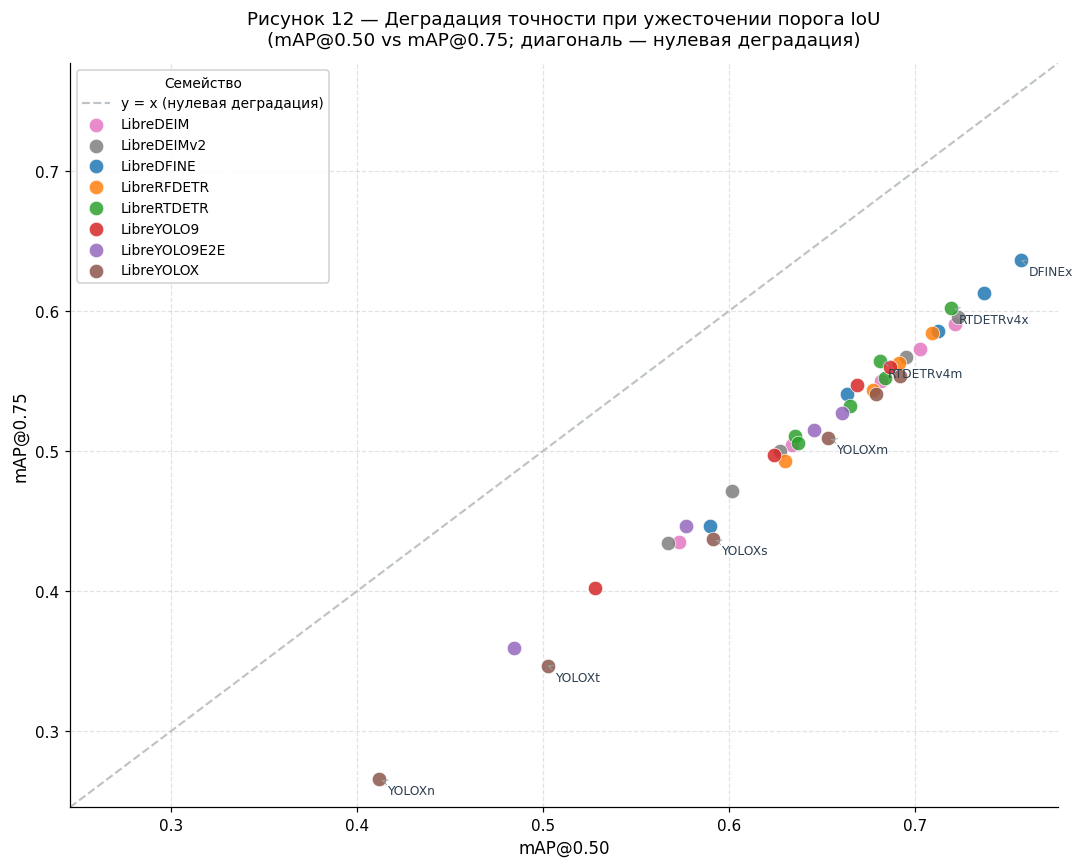

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))

lim_min = min(df['mAP50'].min(), df['mAP75'].min()) - 0.02
lim_max = max(df['mAP50'].max(), df['mAP75'].max()) + 0.02
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color='#bdc3c7', linestyle='--', linewidth=1.4,
        label='y = x (нулевая деградация)', zorder=1)

for family, grp in df.groupby('Family'):
    color = FAMILY_COLORS.get(family, '#aaaaaa')
    ax.scatter(grp['mAP50'], grp['mAP75'],
               color=color, s=90, alpha=0.85,
               edgecolors='white', linewidths=0.5,
               label=family, zorder=3)

df['iou_drop'] = df['mAP50'] - df['mAP75']
annotate_set = pd.concat([df.nlargest(4, 'iou_drop'), df.nsmallest(3, 'iou_drop')])
for _, row in annotate_set.iterrows():
    ax.annotate(
        row['Модель'].replace('Libre', ''),
        (row['mAP50'], row['mAP75']),
        textcoords='offset points', xytext=(5, -10),
        fontsize=8, color='#2c3e50',
        arrowprops=dict(arrowstyle='->', color='#95a5a6', lw=0.6)
    )

ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_xlabel('mAP@0.50', fontsize=11)
ax.set_ylabel('mAP@0.75', fontsize=11)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9,
          title='Семейство', title_fontsize=9)

plt.title(
    'Рисунок 12 — Деградация точности при ужесточении порога IoU\n'
    '(mAP@0.50 vs mAP@0.75; диагональ — нулевая деградация)',
    fontsize=12, pad=12
)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / '12_map50_vs_map75.png', dpi=150, bbox_inches='tight')
plt.show()

*   **Общая тенденция:** Ожидаемо, все модели демонстрируют деградацию метрик при переходе к более строгому порогу IoU. Прослеживается четкий тренд: по мере роста базовой точности (движение вправо по оси X), расстояние до идеальной диагонали визуально сокращается или стабилизируется. Более мощные модели лучше справляются с точной локализацией.
*   **Лидеры устойчивости (Правый верхний угол):** Флагманская модель **DFINEx** демонстрирует не только наивысший базовый показатель mAP@0.50, но и наилучшую устойчивость к жесткому порогу — ее точка располагается выше всех и ближе остальных к линии нулевой деградации. В этой же зоне «высокой точности и стабильности» плотно сгруппированы старшие версии трансформеров RTDETR и DEIM/DEIMv2.
*   **Группировка семейств:** Модели одного семейства выстраиваются в предсказуемые линейные траектории. Трансформерные архитектуры (DFINE, RTDETR) в целом формируют верхний эшелон кластера, в то время как представители YOLO (YOLO9, YOLOX) концентрируются в средней и нижней части распределения, показывая чуть большую относительную деградацию при строгих метриках.

## 7. Тепловая карта нормализованных метрик

Каждый столбец нормализован независимо в диапазон [0, 1],
что позволяет совместно отобразить разнородные показатели.
Строки упорядочены по убыванию mAP@0.50:0.95.

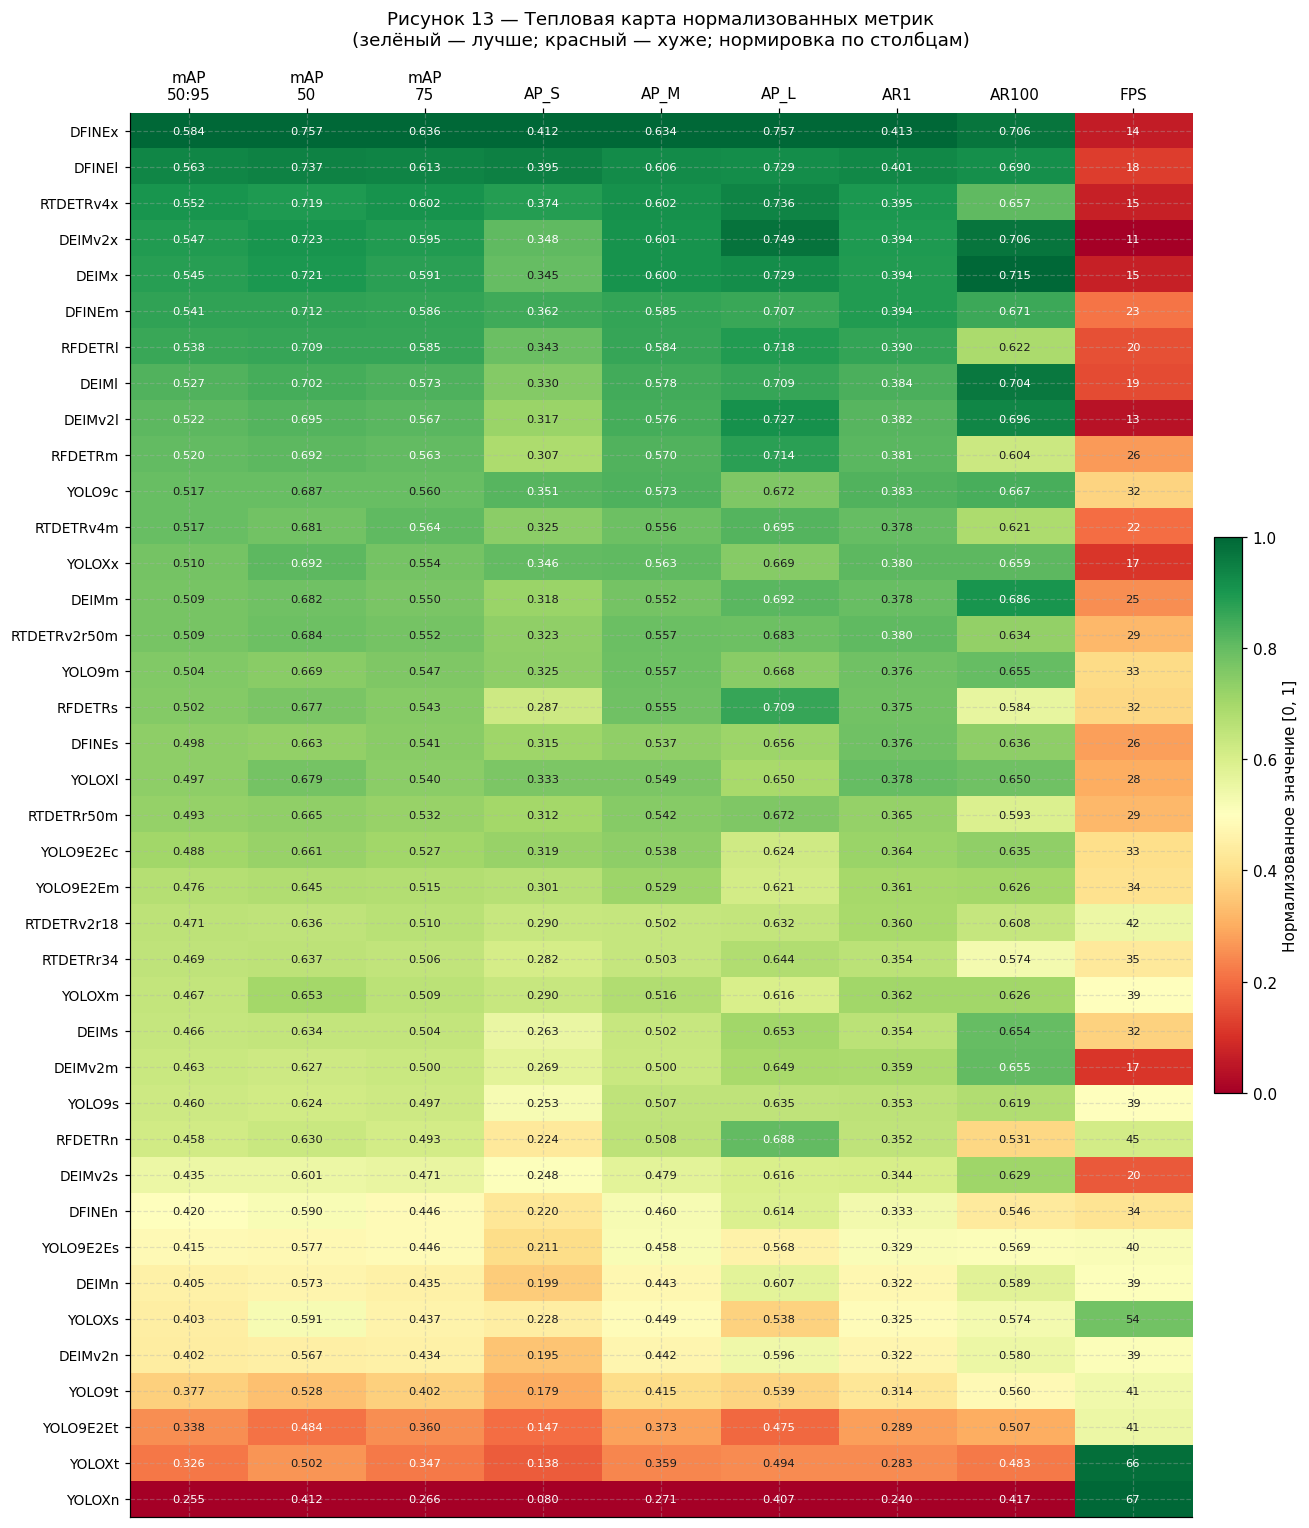

In [29]:
metric_cols = ['mAP50-95','mAP50','mAP75','mAP small','mAP medium','mAP large',
               'AR1','AR100','FPS']
col_labels  = ['mAP\n50:95','mAP\n50','mAP\n75','AP_S','AP_M','AP_L',
               'AR1','AR100','FPS']

heat_df   = df.set_index('Модель')[metric_cols].sort_values('mAP50-95', ascending=False)
heat_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())
heat_df.index   = heat_df.index.str.replace('Libre','',regex=False)
heat_norm.index = heat_norm.index.str.replace('Libre','',regex=False)

fig, ax = plt.subplots(figsize=(12, 14))
im = ax.imshow(heat_norm.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(metric_cols)))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(len(heat_df)))
ax.set_yticklabels(heat_norm.index, fontsize=9)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

for i in range(len(heat_df)):
    for j, col in enumerate(metric_cols):
        val      = heat_df.values[i, j]
        norm_val = heat_norm.values[i, j]
        tc = 'white' if norm_val < 0.22 or norm_val > 0.80 else '#1a1a1a'
        fmt = f'{val:.0f}' if col == 'FPS' else f'{val:.3f}'
        ax.text(j, i, fmt, ha='center', va='center', fontsize=7.5, color=tc)

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Нормализованное значение [0, 1]', fontsize=10)

plt.title(
    'Рисунок 13 — Тепловая карта нормализованных метрик\n'
    '(зелёный — лучше; красный — хуже; нормировка по столбцам)',
    fontsize=12, pad=16
)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / '13_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Тепловая карта наглядно демонстрирует общую расстановку сил среди архитектур и позволяет выявить несколько ключевых паттернов:

**1. Фундаментальный компромисс (Speed-Accuracy Trade-off)**
Самый очевидный визуальный паттерн — это диагональный контраст между блоком метрик качества  и столбцом скорости `FPS`. 
*   **Тяжеловесы (Верхняя часть):** Модели с индексами 'x' и 'l' (DFINEx, RTDETRv4x, DEIMx) окрашены в темно-зеленый цвет по всем метрикам `mAP` и `AP`. Однако их столбец `FPS` горит темно-красным (11-18 FPS). Они обеспечивают максимальную точность ценой невозможности работы в реальном времени на данном железе.
*   **Спринтеры (Нижняя часть):** Нано- и микро-версии (YOLOXn, YOLO9E2Et) показывают отличную скорость (зеленые значения FPS, 50-67), но их метрики качества, особенно на строгих порогах, проседают до критических красных значений.

**2. Доминирование архитектуры DFINE в абсолютном качестве**
Модели **DFINEx** и **DFINEl** уверенно занимают первые строчки рейтинга. Важно отметить, что DFINEx является абсолютным лидером во всех без исключения столбцах метрик точности и полноты (AR), формируя сплошную темно-зеленую строку. 

**3. Проблема детектирования малых объектов (AP_S)**
Столбец `AP_S` (точность на малых объектах) — самый «проблемный» среди метрик качества. Зеленый цвет в нем заканчивается очень быстро, и бóльшая часть таблицы окрашена в желто-оранжевые тона. 
*   Даже уверенные «середняки» сильно теряют в качестве при поиске мелких деталей.
*   В то же время, столбец `AP_L` (крупные объекты) остается зеленым почти до самого низа таблицы. Это доказывает, что детектирование крупных объектов является решенной задачей даже для легких архитектур, тогда как малые объекты требуют тяжелых моделей (таких как DFINE).

**4. Архитектурные аномалии и особенности**
*   **Низкая эффективность DEIMv2 по скорости:** Обращает на себя внимание столбец FPS для моделей семейства **DEIMv2**. Даже средние и малые версии (DEIMv2m — 17 FPS, DEIMv2s — 20 FPS) окрашены в красно-оранжевые цвета. При сопоставимом качестве (например, RFDETRn имеет mAP 0.458 и 45 FPS), DEIMv2s работает более чем в два раза медленнее. Это указывает на высокую алгоритмическую сложность или плохую оптимизацию инференса данной архитектуры.
*   **Баланс (Золотая середина):** Модели, находящиеся в середине таблицы (например, YOLO9c, RFDETRm, RTDETRv2r50m), демонстрируют наиболее сбалансированные показатели — светло-зеленые/желтые оттенки как в блоке качества, так и в блоке скорости (25-33 FPS), что делает их оптимальными кандидатами для практического применения в системах реального времени.

## 8. Сравнение версий

### 8.1. LibreYOLO9 vs LibreYOLO9E2E

E2E-версии исключают этап NMS из постпроцессинга, что теоретически должно снижать задержку.
На практике наблюдается обратное: E2E-варианты уступают базовым как по точности, так и по скорости.

### 8.2. LibreDEIM vs LibreDEIMv2

Архитектура v2 при сопоставимой или незначительно превосходящей точности
существенно медленнее v1 во всех размерных конфигурациях.

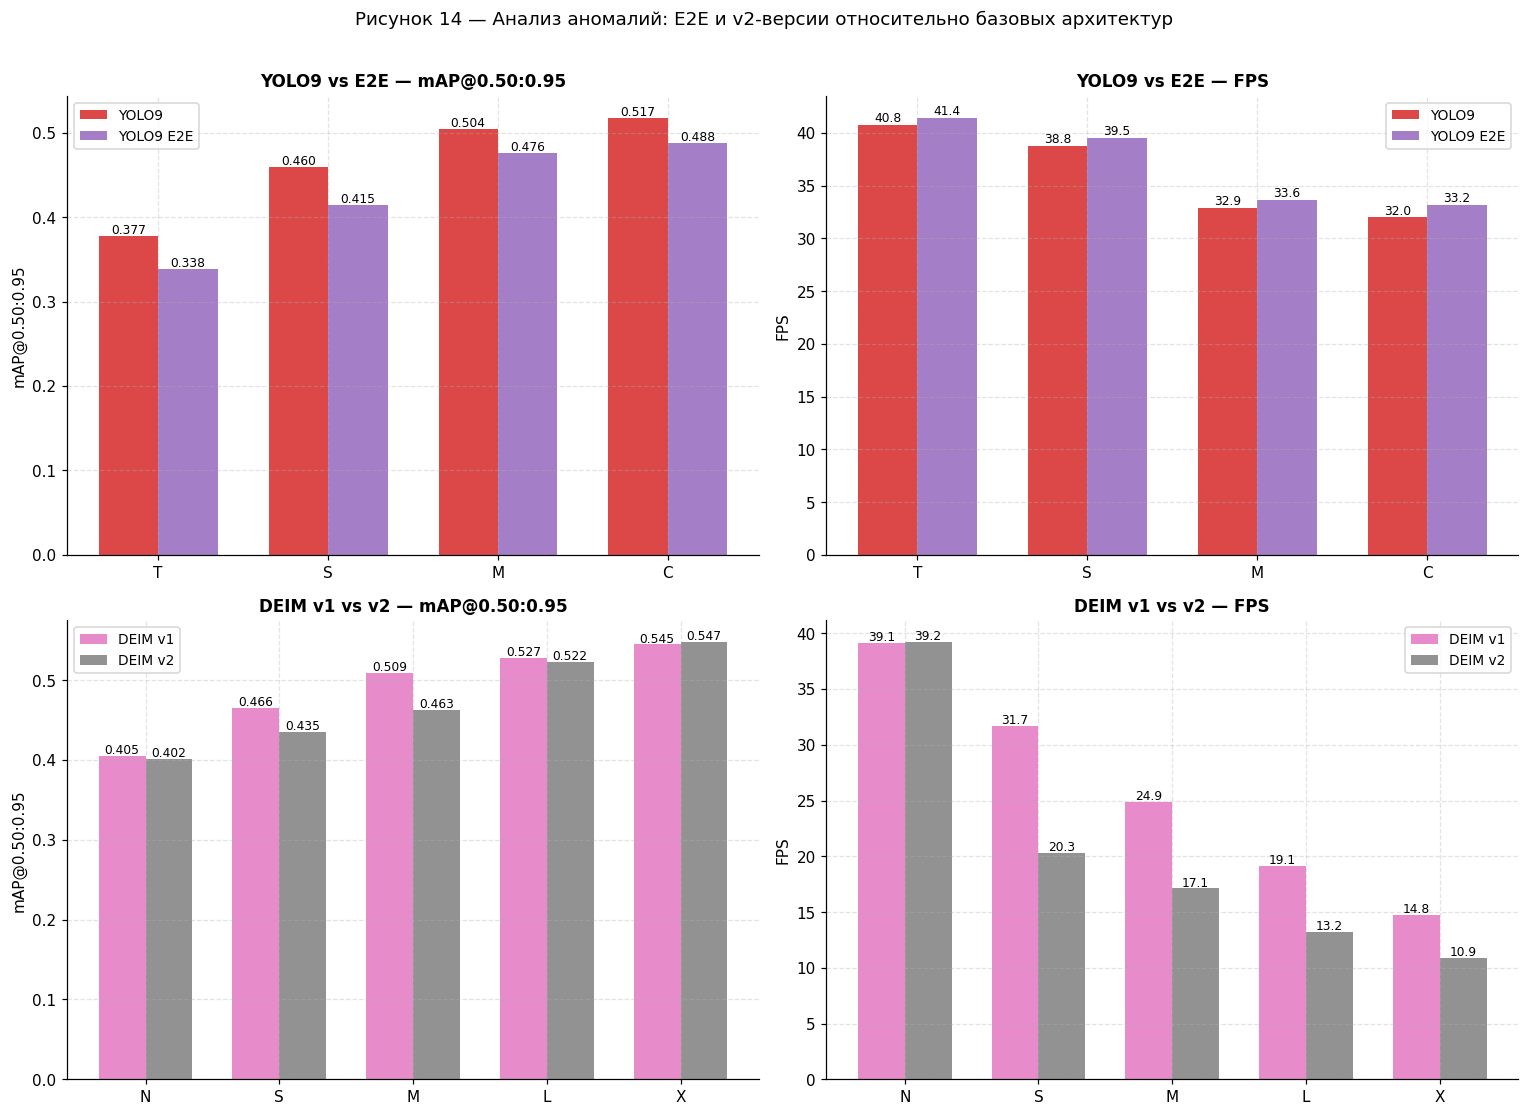

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

w = 0.35

# ---- YOLO9 vs YOLO9E2E ----
sizes_y = ['t','s','m','c']
y9  = df[df['Family']=='LibreYOLO9'].set_index('Size_Code').reindex(sizes_y)
y9e = df[df['Family']=='LibreYOLO9E2E'].set_index('Size_Code').reindex(sizes_y)
x   = np.arange(len(sizes_y))

for col_i, (metric, ylabel, ax) in enumerate([
    ('mAP50-95', 'mAP@0.50:0.95', axes[0,0]),
    ('FPS',      'FPS',           axes[0,1]),
]):
    v1 = y9[metric].values.astype(float)
    v2 = y9e[metric].values.astype(float)
    ax.bar(x - w/2, v1, w, label='YOLO9',     color='#d62728', alpha=0.85)
    ax.bar(x + w/2, v2, w, label='YOLO9 E2E', color='#9467bd', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([s.upper() for s in sizes_y])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'YOLO9 vs E2E \u2014 {ylabel}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    fmt = '.3f' if metric != 'FPS' else '.1f'
    for i, (a, b) in enumerate(zip(v1, v2)):
        if not (np.isnan(a) or np.isnan(b)):
            offset = 0.003 if metric != 'FPS' else 0.3
            ax.text(i - w/2, a + offset, f'{a:{fmt}}', ha='center', fontsize=8)
            ax.text(i + w/2, b + offset, f'{b:{fmt}}', ha='center', fontsize=8)

# ---- DEIM v1 vs v2 ----
sizes_d = ['n','s','m','l','x']
d1 = df[df['Family']=='LibreDEIM'].set_index('Size_Code').reindex(sizes_d)
d2 = df[df['Family']=='LibreDEIMv2'].set_index('Size_Code').reindex(sizes_d)
x2 = np.arange(len(sizes_d))

for col_i, (metric, ylabel, ax) in enumerate([
    ('mAP50-95', 'mAP@0.50:0.95', axes[1,0]),
    ('FPS',      'FPS',           axes[1,1]),
]):
    v1 = d1[metric].values.astype(float)
    v2 = d2[metric].values.astype(float)
    ax.bar(x2 - w/2, v1, w, label='DEIM v1', color='#e377c2', alpha=0.85)
    ax.bar(x2 + w/2, v2, w, label='DEIM v2', color='#7f7f7f', alpha=0.85)
    ax.set_xticks(x2)
    ax.set_xticklabels([s.upper() for s in sizes_d])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'DEIM v1 vs v2 \u2014 {ylabel}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    fmt = '.3f' if metric != 'FPS' else '.1f'
    for i, (a, b) in enumerate(zip(v1, v2)):
        if not (np.isnan(a) or np.isnan(b)):
            offset = 0.003 if metric != 'FPS' else 0.2
            ax.text(i - w/2, a + offset, f'{a:{fmt}}', ha='center', fontsize=8)
            ax.text(i + w/2, b + offset, f'{b:{fmt}}', ha='center', fontsize=8)

fig.suptitle(
    'Рисунок 14 — Анализ аномалий: E2E и v2-версии относительно базовых архитектур',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / '14_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

**1. Проблема YOLO9 E2E: Неоправданная потеря точности**

Концепция End-to-End (E2E) в детекторах обычно подразумевает отказ от пост-процессинга (NMS) ради ускорения инференса. Однако графики демонстрируют неудачный компромисс:
*   **Систематическая деградация mAP:** На всех размерных конфигурациях (от T до C) версия E2E стабильно уступает базовой YOLO9. Падение метрики mAP@0.50:0.95 составляет в среднем **0.03–0.04**, что является существенным снижением качества локализации.
*   **Иллюзорное ускорение:** Ожидаемого прироста в скорости не произошло. Столбцы FPS показывают, что E2E версия работает быстрее базовой лишь на ничтожные доли кадра (прирост менее 1 FPS на всех конфигурациях).
*   **Вывод:** Использование архитектуры YOLO9 E2E нецелесообразно. Модель жертвует значительной долей точности, не предоставляя взамен никаких реальных преимуществ в скорости.

**2. Архитектурный регресс DEIMv2**

Обновление мажорной версии (до v2) традиционно подразумевает улучшение баланса между скоростью и точностью. В случае с DEIM наблюдается обратная, аномальная картина:
*   **Провал в среднем сегменте точности:** Версия v2 не принесла улучшения метрик mAP. На крайних размерах (N и X) точность осталась практически идентичной v1. Однако на средних конфигурациях (S и M) наблюдается резкое падение качества — версия DEIMv2m уступает предшественнице целых **0.046 mAP**.
*   **Катастрофическое падение скорости (FPS):** Главной проблемой DEIMv2 является сильная деградация производительности. За исключением нано-версии (N), все остальные конфигурации работают значительно медленнее v1. Например, базовая версия 'S' выдает 31.7 FPS, тогда как 'v2 S' проседает до 20.3 FPS (потеря более 30% скорости).
*   **Вывод:** В текущей реализации архитектура DEIMv2 выглядит неоптимизированной. Обновление привело к резкому снижению скорости инференса без каких-либо дивидендов в виде повышения точности, делая первую версию (DEIM v1) предпочтительным выбором.

### 8.3. LibreRTDETR: эволюция архитектуры (v1 → v2 → v4)

Каждая версия архитектуры RTDETRобъединяет несколько размерных конфигураций.
Линии соединяют модели одной версии, образуя «версионный фронт» на плоскости
точность — быстродействие. Смещение фронта вверх и вправо означает улучшение архитектуры.

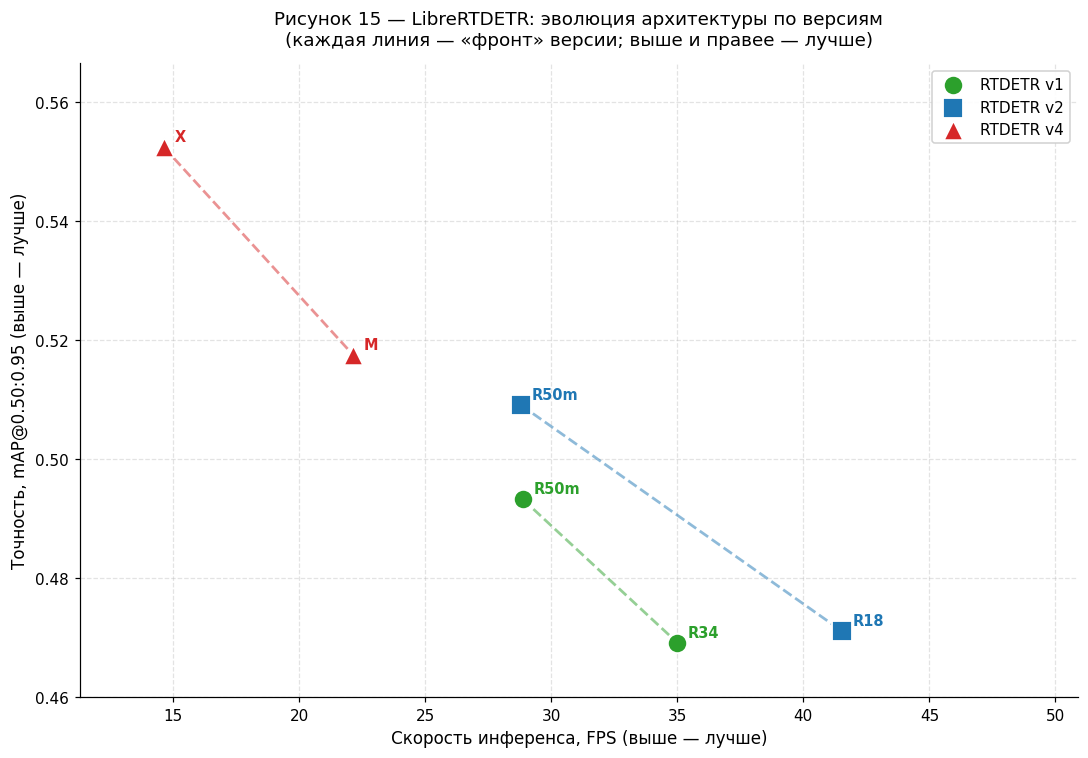

In [ ]:
rtdetr = df[df['Family'] == 'LibreRTDETR'].copy()

version_map = {
    'LibreRTDETRr34':    ('v1', 'R34'),
    'LibreRTDETRr50m':   ('v1', 'R50m'),
    'LibreRTDETRv2r18':  ('v2', 'R18'),
    'LibreRTDETRv2r50m': ('v2', 'R50m'),
    'LibreRTDETRv4m':    ('v4', 'M'),
    'LibreRTDETRv4x':    ('v4', 'X'),
}
rtdetr['Version']  = rtdetr['Модель'].map(lambda m: version_map.get(m, ('?','?'))[0])
rtdetr['Backbone'] = rtdetr['Модель'].map(lambda m: version_map.get(m, ('?','?'))[1])

version_styles = {
    'v1': {'color': '#2ca02c', 'marker': 'o', 'label': 'RTDETR v1'},
    'v2': {'color': '#1f77b4', 'marker': 's', 'label': 'RTDETR v2'},
    'v4': {'color': '#d62728', 'marker': '^', 'label': 'RTDETR v4'},
}

fig, ax = plt.subplots(figsize=(10, 7))

for ver, style in version_styles.items():
    grp = rtdetr[rtdetr['Version'] == ver].sort_values('FPS')
    if len(grp) < 1:
        continue
    ax.plot(grp['FPS'], grp['mAP50-95'],
            color=style['color'], linewidth=1.8,
            linestyle='--', alpha=0.5, zorder=2)

for ver, style in version_styles.items():
    grp = rtdetr[rtdetr['Version'] == ver].sort_values('FPS')
    ax.scatter(grp['FPS'], grp['mAP50-95'],
               color=style['color'], marker=style['marker'],
               s=160, zorder=4, edgecolors='white', linewidths=1.2,
               label=style['label'])
    # Подпись рядом с каждой точкой
    for _, row in grp.iterrows():
        ax.annotate(
            row['Backbone'],
            (row['FPS'], row['mAP50-95']),
            textcoords='offset points', xytext=(7, 4),
            fontsize=9.5, color=style['color'], fontweight='bold'
        )

ax.set_xlabel('Скорость инференса, FPS (выше — лучше)', fontsize=11)
ax.set_ylabel('Точность, mAP@0.50:0.95 (выше — лучше)', fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)

# Небольшие отступы чтобы подписи не обрезались
ax.set_xlim(ax.get_xlim()[0] - 2, ax.get_xlim()[1] + 8)
ax.set_ylim(ax.get_ylim()[0] - 0.005, ax.get_ylim()[1] + 0.01)

plt.title(
    'Рисунок 15 — LibreRTDETR: эволюция архитектуры по версиям\n'
    '(каждая линия — «фронт» версии; выше и правее — лучше)',
    fontsize=12, pad=12
)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / '15_rtdetr_versions.png', dpi=150, bbox_inches='tight')
plt.show()


- Переход v1 → v2 при сохранении backbone R50m даёт прирост mAP@0.50:0.95
с 0.493 до 0.509 (+3.2%) без потери скорости (28.87 vs 28.80 FPS).
Показательно, что v2 на облегчённом backbone R18 (41.6 FPS, mAP = 0.471)
превосходит v1/R34 (35.0 FPS, mAP = 0.469) одновременно по обеим метрикам —
новая архитектура эффективнее использует меньший backbone.

- Версия v4 формирует отдельный высокоточный сегмент: v4/M достигает mAP = 0.517
при 22.2 FPS, v4/X — mAP = 0.552 при 14.6 FPS. По сравнению с лучшей моделью v2
прирост точности составляет +4.3–8.5%, однако скорость снижается вдвое и более.


## 9. Выводы

### 9.1. Общие результаты

Семейство **LibreDFINE** демонстрирует наибольшую точность во всех весовых категориях:
от LibreDFINEn (mAP = 0.420) до LibreDFINEx (mAP = 0.584).
Семейство **LibreYOLOX** обеспечивает наибольшую скорость инференса:
LibreYOLOXn — 66.6 FPS при mAP = 0.255.

### 9.2. Оптимальные модели по критериям применения

| Критерий | Модель | mAP@0.50:0.95 | FPS |
|:---|:---:|:---:|:---:|
| Максимальная точность | LibreDFINEx | 0.584 | 14.3 |
| Точность при ограниченной задержке | LibreDFINEl | 0.563 | 17.8 |
| Оптимальный баланс — компактные | LibreRTDETRv2r18 | 0.471 | 41.6 |
| Оптимальный баланс — средние | LibreYOLO9c | 0.518 | 32.0 |
| Максимальное быстродействие | LibreYOLOXn | 0.255 | 66.6 |

### 9.3. Выявленные аномалии

**LibreYOLO9E2E.** E2E-версии уступают базовым по обеим метрикам — по точности и по скорости.
При batch=1 вычислительная стоимость встроенного механизма внимания превышает затраты
на стандартный NMS.

**LibreDEIMv2.** При незначительно превосходящей точности v2 существенно медленнее v1
во всех размерных конфигурациях. Наиболее выражено в категории Small:
DEIM v1 — 31.7 FPS, DEIM v2 — 20.3 FPS при разнице по mAP в 0.003.